In [164]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector

In [165]:
dataset = pd.read_csv(r'D:\HopeAI\Training\Week9-ML and Data Science Capstone\1. Data Collection\real_estate_dataset.csv')
dataset

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1.0,3.0,3.0,1967.0,1.0,1.0,48.0,8.297631,5.935734,602134.816747
1,2,287.678577,1.0,2.0,1.0,1949.0,0.0,1.0,37.0,6.061466,10.827392,591425.135386
2,3,232.998485,1.0,3.0,2.0,1923.0,1.0,0.0,14.0,2.911442,6.904599,464478.696880
3,4,199.664621,5.0,2.0,2.0,1918.0,0.0,0.0,17.0,2.070949,8.284019,583105.655996
4,5,89.004660,4.0,3.0,3.0,1999.0,1.0,0.0,34.0,1.523278,14.648277,619879.142523
...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,NaN,2.0,2.0,2.0,1967.0,1.0,0.0,16.0,4.296086,5.562583,488496.350722
496,497,195.914028,2.0,3.0,1.0,1977.0,0.0,1.0,45.0,7.406261,2.845105,657736.921717
497,498,69.433659,1.0,1.0,2.0,2004.0,0.0,0.0,18.0,8.629724,6.263264,405324.950201
498,499,293.598702,NaN,1.0,3.0,1940.0,NaN,0.0,41.0,5.318891,16.990684,773035.968028


# Data Preprocessing

In [166]:
#Check of null values in rows
dataset.isnull().sum()

ID                     0
Square_Feet           25
Num_Bedrooms          25
Num_Bathrooms         25
Num_Floors            25
Year_Built            25
Has_Garden            25
Has_Pool              25
Garage_Size           25
Location_Score        25
Distance_to_Center    25
Price                 25
dtype: int64

In [167]:
#Handle missing values

dataset = dataset.dropna()

In [168]:
# Fill with mean
dataset.fillna(dataset.mean())

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1.0,3.0,3.0,1967.0,1.0,1.0,48.0,8.297631,5.935734,602134.816747
1,2,287.678577,1.0,2.0,1.0,1949.0,0.0,1.0,37.0,6.061466,10.827392,591425.135386
2,3,232.998485,1.0,3.0,2.0,1923.0,1.0,0.0,14.0,2.911442,6.904599,464478.696880
3,4,199.664621,5.0,2.0,2.0,1918.0,0.0,0.0,17.0,2.070949,8.284019,583105.655996
4,5,89.004660,4.0,3.0,3.0,1999.0,1.0,0.0,34.0,1.523278,14.648277,619879.142523
...,...,...,...,...,...,...,...,...,...,...,...,...
492,493,119.345296,4.0,3.0,2.0,1966.0,1.0,0.0,25.0,7.219292,6.937720,619610.370076
493,494,97.030290,5.0,1.0,1.0,1948.0,0.0,0.0,45.0,3.848036,8.712896,492310.608883
496,497,195.914028,2.0,3.0,1.0,1977.0,0.0,1.0,45.0,7.406261,2.845105,657736.921717
497,498,69.433659,1.0,1.0,2.0,2004.0,0.0,0.0,18.0,8.629724,6.263264,405324.950201


In [169]:
# Fill with median
dataset['Square_Feet'].fillna(dataset['Square_Feet'].mean(), inplace=True)

C:\Users\kgopi\anaconda3\envs\Training\lib\site-packages\pandas\core\generic.py:6287: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._update_inplace(new_data)


# # Univariate
    

In [36]:
from Univariate import Univariate

#Seggregate Quantitative and Qualitative data
quan,qual = Univariate.Quanqual(dataset)

In [37]:
dataset[quan]

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1.0,3.0,3.0,1967.0,1.0,1.0,48.0,8.297631,5.935734,602134.816747
1,2,287.678577,1.0,2.0,1.0,1949.0,0.0,1.0,37.0,6.061466,10.827392,591425.135386
2,3,232.998485,1.0,3.0,2.0,1923.0,1.0,0.0,14.0,2.911442,6.904599,464478.696880
3,4,199.664621,5.0,2.0,2.0,1918.0,0.0,0.0,17.0,2.070949,8.284019,583105.655996
4,5,89.004660,4.0,3.0,3.0,1999.0,1.0,0.0,34.0,1.523278,14.648277,619879.142523
...,...,...,...,...,...,...,...,...,...,...,...,...
492,493,119.345296,4.0,3.0,2.0,1966.0,1.0,0.0,25.0,7.219292,6.937720,619610.370076
493,494,97.030290,5.0,1.0,1.0,1948.0,0.0,0.0,45.0,3.848036,8.712896,492310.608883
496,497,195.914028,2.0,3.0,1.0,1977.0,0.0,1.0,45.0,7.406261,2.845105,657736.921717
497,498,69.433659,1.0,1.0,2.0,2004.0,0.0,0.0,18.0,8.629724,6.263264,405324.950201


In [38]:
#Get Unique Values	Frequency	Relative Frequency	Cummulative Frequency
Univariate.getFrequency(dataset, quan)["Square_Feet"]


,Unique Values,Frequency,Relative Frequency,Cummulative Frequency
0,181.189108,1,0.003521,1
1,264.122460,1,0.003521,2
2,90.202013,1,0.003521,3
3,296.721734,1,0.003521,4
4,131.295831,1,0.003521,5
...,...,...,...,...
279,212.490983,1,0.003521,280
280,238.093632,1,0.003521,281
281,252.099337,1,0.003521,282
282,110.463073,1,0.003521,283


In [39]:
#Get all values 
Univariate.CreateDataFrame(dataset, quan)

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
Mean,243.785,177.136,2.87324,2.03169,1.97887,1956.99,0.528169,0.5,30.4965,5.21795,9.92742,583368
Median,234.5,180.982,3,2,2,1959,1,0.5,30,5.2207,10.1033,582208
Mode,1,51.3805,1,3,2,1959,1,0,20,0.00442781,0.0628181,298872
Q1:25%,121.5,111.992,2,1,1,1925,0,0,20.75,2.90865,5.53369,509708
Q2:50%,234.5,180.982,3,2,2,1959,1,0.5,30,5.2207,10.1033,582208
Q3:75%,366.25,240.248,4,3,3,1986,1,1,41,7.77879,14.6674,648460
99%,494.51,296.856,5,3,3,2017.17,1,1,49,9.92874,19.6285,860742
Q4:100%,500,298.241,5,3,3,2020,1,1,49,9.99544,19.7844,885909
IQR,244.75,128.257,2,2,2,61,1,1,20.25,4.87013,9.13366,138752
1.5Rule,367.125,192.385,3,3,3,91.5,1.5,1.5,30.375,7.3052,13.7005,208128


# # Bivariant
# # Variance_Inflation_Factor

In [40]:
#Variance_Inflation_Factor
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [41]:
calc_vif(dataset[['Location_Score', 'Distance_to_Center']])

,variables,VIF
0,Location_Score,2.511863
1,Distance_to_Center,2.511863


# # Independant Sample- Unpaired T Test

In [42]:
# Diferrent Group(Has Garden) but same contion(Price)

from scipy.stats import ttest_ind

Has_Garden = dataset[dataset['Has_Garden'] == 1]['Price']
No_Garden = dataset[dataset['Has_Garden'] == 0]['Price']
ttest_ind(Has_Garden, No_Garden)


Ttest_indResult(statistic=0.9004553926361031, pvalue=0.36864627759430013)

# # ANAVO : Analysis of Variance

In [43]:
import scipy.stats as stats

g1 = dataset[dataset['Num_Floors'] == 1]['Price']
g2 = dataset[dataset['Num_Floors'] == 2]['Price']
g3 = dataset[dataset['Num_Floors'] == 3]['Price']

stats.f_oneway(g1, g2, g3)

F_onewayResult(statistic=7.580811496103643, pvalue=0.0006215043342182975)

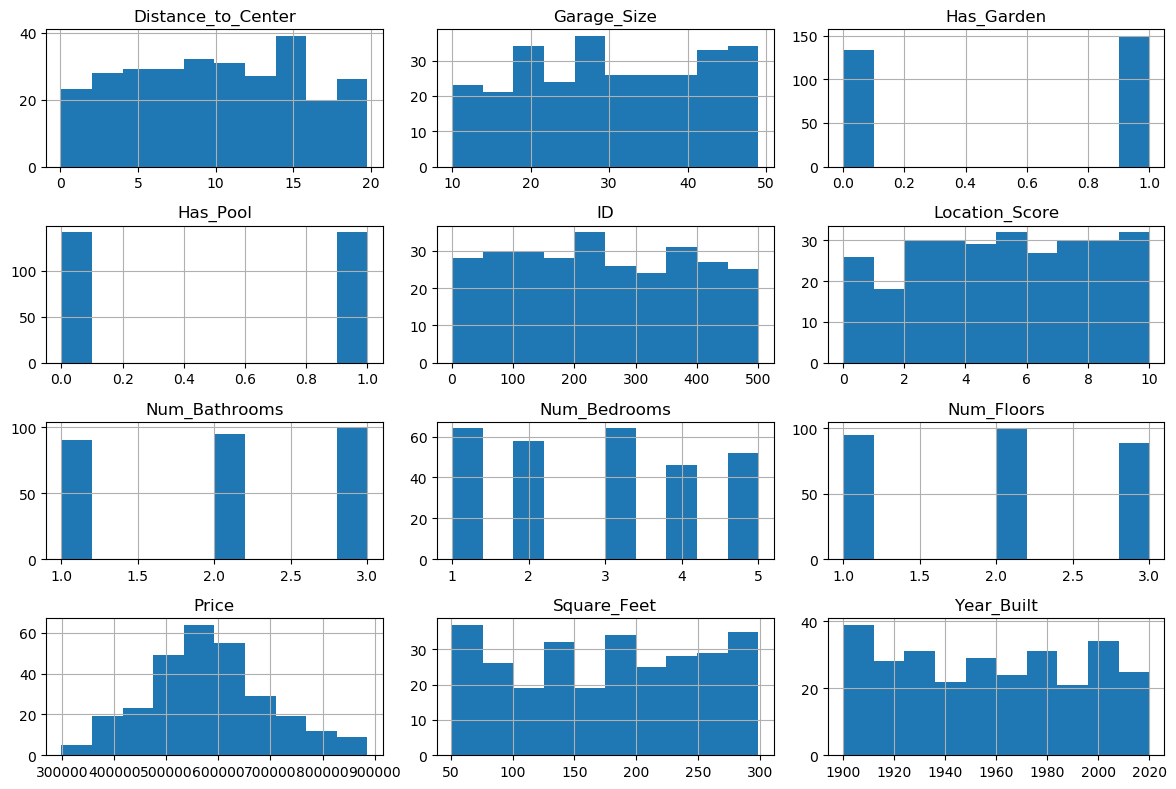

In [44]:
# Histograms Plot

dataset.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

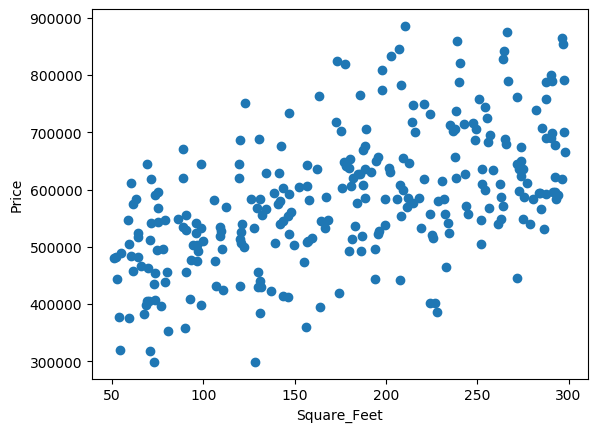

In [45]:
# Scattered Plot

import matplotlib.pyplot as plt

plt.scatter(dataset['Square_Feet'], dataset['Price'])
plt.xlabel('Square_Feet')
plt.ylabel('Price')
plt.show()

In [170]:
X_ind = dataset.drop(columns=['ID','Price'])
Y_Dep=dataset['Price']

In [171]:
X_train, X_test, y_train, y_test = train_test_split(X_ind, Y_Dep, test_size = 1/3, random_state = 0)

In [172]:
#Preprocessing input
scx= StandardScaler()
X_train_3 = X_train[['Square_Feet', 'Location_Score', 'Distance_to_Center']]
X_test_3 = X_test[['Square_Feet','Location_Score', 'Distance_to_Center']]

X_train_3 = scx.fit_transform(X_train_3)
X_test_3 = scx.transform(X_test_3)

In [173]:
#Feature Selection
def ForwardBackwardSelection(direction, X_Train):
    
    from sklearn.linear_model import LinearRegression
    from sklearn.svm import SVC
    from sklearn.svm import SVR
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.tree import DecisionTreeClassifier

    models = {
        "Linear": LinearRegression(),
        "SVC": SVC(),
        "RandomForest": RandomForestClassifier(),
        "DecisionTree": DecisionTreeClassifier(),
        "SVR": SVR(kernel="rbf",C=1000)
    }

    print(direction,"selection :")

    for name, model in models.items():
        
        if (direction == 'forward'):
            sfs = SequentialFeatureSelector(model, n_features_to_select=2, direction="forward")
        else:
            sfs = SequentialFeatureSelector(model, n_features_to_select=2, direction="backward",cv=5, scoring='r2', n_jobs=1)
        sfs.fit(X_Train, y_train)
        selected = X_Train.columns[sfs.get_support()]
        
        
        print(name, "Selected Features:", list(selected))

In [174]:
X_Train = pd.DataFrame(X_train_3, columns=['Square_Feet','Location_Score', 'Distance_to_Center'])
ForwardBackwardSelection("forward", X_Train)

forward selection :
Linear Selected Features: ['Square_Feet', 'Location_Score']
SVC Selected Features: ['Square_Feet', 'Location_Score']
RandomForest Selected Features: ['Square_Feet', 'Location_Score']
DecisionTree Selected Features: ['Square_Feet', 'Location_Score']
SVR Selected Features: ['Square_Feet', 'Distance_to_Center']


C:\Users\kgopi\anaconda3\envs\Training\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
5 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\kgopi\anaconda3\envs\Training\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\kgopi\anaconda3\envs\Training\lib\site-packages\sklearn\svm\_base.py", line 199, in fit
    y = self._validate_targets(y)
  File "C:\Users\kgopi\anaconda3\envs\Training\lib\site-packages\sklearn\svm\_base.py", line 716, in _validate_targets
    check_classification_ta

In [175]:
ForwardBackwardSelection("backward", X_Train)

backward selection :
Linear Selected Features: ['Square_Feet', 'Location_Score']
SVC Selected Features: ['Location_Score', 'Distance_to_Center']
RandomForest Selected Features: ['Location_Score', 'Distance_to_Center']
DecisionTree Selected Features: ['Location_Score', 'Distance_to_Center']
SVR Selected Features: ['Square_Feet', 'Distance_to_Center']


C:\Users\kgopi\anaconda3\envs\Training\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
5 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\kgopi\anaconda3\envs\Training\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\kgopi\anaconda3\envs\Training\lib\site-packages\sklearn\svm\_base.py", line 199, in fit
    y = self._validate_targets(y)
  File "C:\Users\kgopi\anaconda3\envs\Training\lib\site-packages\sklearn\svm\_base.py", line 716, in _validate_targets
    check_classification_ta

In [176]:
scy=StandardScaler()
y_train = scy.fit_transform(y_train.values.reshape(-1,1)) # Without reshare giving error of 1D shape
y_test = scy.transform(y_test.values.reshape(-1,1))

In [177]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train_3, y_train)

LinearRegression()

In [178]:
y_pred=regressor.predict(X_test_3)
y_pred

array([[-0.66059634],
       [-0.74998642],
       [ 0.31806107],
       [-0.80745261],
       [ 0.44459133],
       [-0.73910085],
       [-1.1255202 ],
       [-0.61621422],
       [-0.10801722],
       [ 0.32536783],
       [ 0.32488696],
       [ 0.78871461],
       [-0.27262122],
       [ 0.45116191],
       [ 0.09427412],
       [ 0.32586997],
       [-0.42720611],
       [ 0.98668363],
       [ 0.32547554],
       [ 0.08861849],
       [ 0.58919579],
       [ 0.18038952],
       [ 0.76927698],
       [ 0.38312761],
       [ 0.74707293],
       [ 0.76486069],
       [-0.57255338],
       [ 0.62394581],
       [-0.81418037],
       [-0.86001716],
       [-0.60404779],
       [-0.96554174],
       [-0.66598864],
       [-0.03906826],
       [ 0.94052834],
       [ 0.25575974],
       [ 0.43376431],
       [ 0.79444079],
       [ 0.60041108],
       [-0.36504892],
       [-0.44272956],
       [ 0.95376766],
       [-0.14289975],
       [ 0.61787635],
       [ 0.49324272],
       [-0

In [179]:
r_score=r2_score(y_test,y_pred)
r_score

0.24904537738355836

In [180]:
import pickle
filename = "finalized_model_svr.sav"
pickle.dump(regressor, open(filename,'wb'))

In [181]:
preinput= scx.transform([[177.136,5.21795,9.92742]])
preinput

C:\Users\kgopi\anaconda3\envs\Training\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  "X does not have valid feature names, but"


array([[ 0.05373136, -0.00634575,  0.07482543]])

In [182]:
loaded_model = pickle.load(open("finalized_model_svr.sav", 'rb'))
result= loaded_model.predict(preinput)
result

array([[0.0231712]])

In [189]:
preoutput = scy.inverse_transform(result)
print("The predicted price for house with 177.136 SQ ft, Location_Score=5.21795, Distance_to_Center=9.92742 is")
print(preoutput[0][0])

The predicted price for house with 177.136 SQ ft, Location_Score=5.21795, Distance_to_Center=9.92742 is
572345.6387448987
